In [2]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as matpy

from sklearn.model_selection import train_test_split
import sklearn as skl
#from sklearn.tree import DecisionTreeClassifier
#from sklearn.metrics import accuracy_score

Wir deklarieren die entsprechenden 10 Kategorien für unseren Fashion-MNSIT Trainingsdatensatz

In [3]:
LABELS = {
    0: "T-Shirt/Oberteil",
    1: "Hose",
    2: "Pullover",
    3: "Kleid",
    4: "Mantel",
    5: "Sandale",
    6: "Hemd",
    7: "Sneaker",
    8: "Tasche",
    9: "Stiefelette"
}

Wir importieren den Datensatz und geben einen kleinen Auschnitt zur Probe aus

In [4]:
bsp = pd.read_csv("fashion-mnist_train.csv", nrows=10)
bsp.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


( Wir möchten nun gucken, ob wir die Bilder richtig visualisieren können.

Streng genommen bringt dieser Schritt unserem Modell nichts.

Er wird für unser Verständnis aber trotzdem vom Vorteil sein. )


In [5]:
zeile = bsp.iloc[1]         # nimmt die zweite Zeile, also die erste mit kommagetrennten Zahlen
label = zeile.iloc[0]       # nimmt den ersten Wert dieser Spalte, also das Label, welcher Klasse das Kleidungsstück angehört
pixel = zeile.iloc[1:]      # die restlichen 784 kommagetrennten Graustufenwerte [0 bis 255]

Visuelle Ausgabe der kommagetrennten Graustufenwerte als Bild

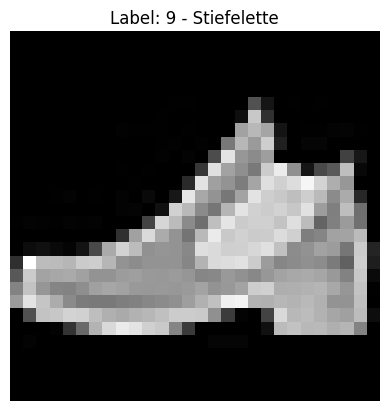

In [6]:
bild = numpy.array(zeile[1:], dtype=numpy.uint8).reshape(28,28)         # Um das Bild visualisieren zu können, wandeln wir es in ein 28*28 Array um.
matpy.imshow(bild, cmap='gray')
matpy.axis("off")
matpy.title(f"Label: {label} - {LABELS[label]}")
matpy.show()

Nun möchten wir das Bild in 16 Farbgruppen mit je 16 Graustufen unterteilen ~> {{0, ... , 15}, ... , {240, ... , 255}}

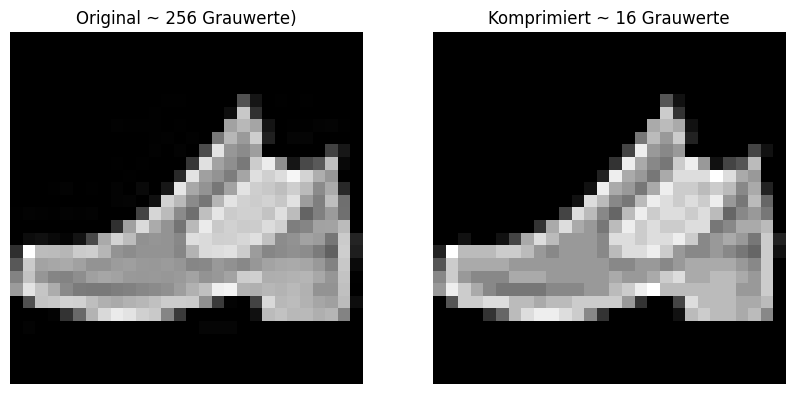

In [7]:
# Dieser Codeblock wurde mit KI generiert
bild_transformed = (bild / 16).astype(numpy.uint8)
fig, axes = matpy.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(bild, cmap='gray', vmin=0, vmax=255)
axes[0].axis("off")
axes[0].set_title(f"Original ~ 256 Grauwerte)")
axes[1].imshow(bild_transformed, cmap='gray', vmin=0, vmax=15)
axes[1].axis("off")
axes[1].set_title("Komprimiert ~ 16 Grauwerte")
matpy.show()

Wir sehen also, wenn auch nur an einem Beispiel, das wird das Bild anscheinend fast verlustfrei, komprimieren können. Das machen wir natürlich nicht um Speicherplatz zu sparen, denn das Bild ist bereits sehr klein. Aber dadurch können wir den Rechenaufwand beim Ausführen der Random Trees drastisch reduzieren. Noch enormere Auswirkungen dürfte diese Gruppierung allerdings für andere Klassifikationsmethoden haben.

---

Nun kommen wir zum Klassifikationsteil, also der Lösung des ursprünglichen Problems

---

Wir definieren hier die Funktion um die Pixel in die 16 Gruppen der Graustufen einzuordnen

In [8]:
def group_16(data):
    data.iloc[:, 1:] = (data.iloc[:, 1:] // 16).astype(int)
    return data

In [9]:
group_16(bsp)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,1,2,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,12,13,10,0,0,0,0,0,0,0


In [10]:
def bootstrap(data, rows):
    return data.sample(n = rows, replace = True)

In [11]:
bootstrap(bsp, 10)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
8,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,1,2,0,0,0,0,0
2,6,0,0,0,0,0,0,0,0,0,...,0,0,0,1,2,0,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
train = pd.read_csv("fashion-mnist_train.csv")
train = group_16(train)
xTrain = train.iloc[:, 1:]    # wählt alle (784) kommagetrennten Werte außer dem ersten aus.
yTrain = train.iloc[:, 0]     # wählt nur die Klassifikationsziffer aus.

test = pd.read_csv("fashion-mnist_test.csv")
test = group_16(test)
xTest = test.iloc[:, 1:]    # wählt alle (784) kommagetrennten Werte außer dem ersten aus.
yTest = test.iloc[:, 0]     # wählt nur die Klassifikationsziffer aus.

In [13]:
#counts = yTrain.value_counts().reindex(range(10), fill_value=0)
#result_vector = counts.values
#print(result_vector)

---
Random Forest
---
---


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

B_trees = 100  # Anzahl der Bäume
m_features = int(numpy.sqrt(xTrain.shape[1]))  # Ist als HYPERPARAMETER Standardmäßig die Wurzel der Features, da wir 28*28 haben also = 28
n_trainDataSets = xTrain.shape[0]  # Anzahl der ausgewerteten Datensätze

trees = []

print("Anzahl der zufällig ausgewählten Pixel pro Baum = Wurzel der Features =", m_features)

for i in range(B_trees):
    # Bootstrap Sample erstellen
    boot_data = bootstrap(pd.concat([yTrain, xTrain], axis=1),n_trainDataSets)
    Xb = boot_data.iloc[:, 1:]
    yb = boot_data.iloc[:, 0]

    # Auswahl der zufälligen Features (Schlüsselidee des Random Forests)
    cols = numpy.random.choice(xTrain.columns, m_features, replace=False)

    # Entscheidungsbaum
    tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=None,
        random_state=i      # hierdurch wird gewährleistet, dass wir für jeden Durchlauf (Tree) unterschiedliche Features (Pixel) bewerten
    )
    tree.fit(Xb[cols], yb)

    # Baum + verwendete Spalten speichern
    trees.append((tree, cols))


Anzahl der zufällig ausgewählten Pixel pro Baum = Wurzel der Features = 28


Auswertung (Zählung) der durch den Random Forests generierten und Berechnung der Genauigkeit (Accuracy Score)

In [14]:
def forest_predict(trees, X):
    predictions = []

    for tree, cols in trees:
        p = tree.predict(X[cols])
        predictions.append(p)

    predictions = numpy.array(predictions)

    # Mehrheit pro Sample
    majorityVote = numpy.apply_along_axis(
        lambda x: numpy.bincount(x).argmax(),
        axis=0,
        arr=predictions
    )
    return majorityVote


# Testdaten klassifizieren
y_pred = forest_predict(trees, xTest)

# Genauigkeit berechnen
acc = accuracy_score(yTest, y_pred)
print("Accuracy Score des Random Forests:", acc)


Accuracy Score des Random Forests: 0.8622


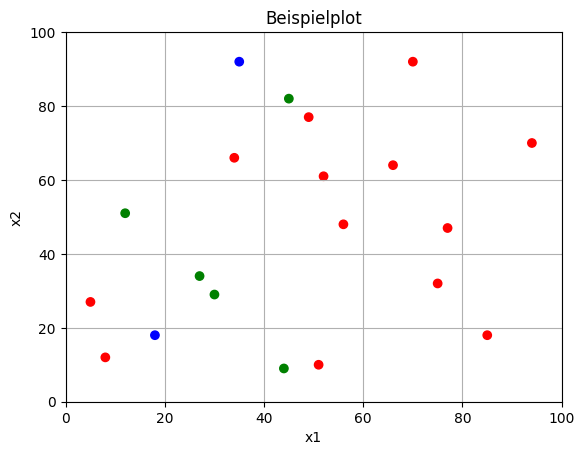

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Generate random integer points
x = np.random.randint(5, 95, 20)
y = np.random.randint(5, 95, 20)

# Define colors
colors = ['red'] * 13 + ['green'] * 5 + ['blue'] * 2

# Create the plot
plt.scatter(x, y, c=colors)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.title('Beispielplot')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()


In [9]:
# Poker Game

import random

class Card:
    suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
    ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'Jack', 'Queen', 'King', 'Ace']

    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def __str__(self):
        return f"{self.rank} of {self.suit}"

class Deck:
    def __init__(self):
        self.cards = [Card(suit, rank) for suit in Card.suits for rank in Card.ranks]
        random.shuffle(self.cards)

    def deal(self):
        return self.cards.pop()

class Player:
    def __init__(self, name):
        self.name = name
        self.hand = []

    def add_card(self, card):
        self.hand.append(card)

    def show_hand(self):
        return ', '.join(str(card) for card in self.hand)

class PokerGame:
    def __init__(self, player_names):
        self.deck = Deck()
        self.players = [Player(name) for name in player_names]

    def deal_hands(self):
        for _ in range(2):  # Each player gets 2 cards
            for player in self.players:
                player.add_card(self.deck.deal())

    def show_hands(self):
        for player in self.players:
            print(f"{player.name}'s hand: {player.show_hand()}")

if __name__ == "__main__":
    player_names = ['Alice', 'Bob']
    game = PokerGame(player_names)
    game.deal_hands()
    game.show_hands()


Alice's hand: 2 of Hearts, Queen of Diamonds
Bob's hand: 6 of Diamonds, 6 of Hearts


In [10]:
import random

class Card:
    suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
    ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'Jack', 'Queen', 'King', 'Ace']

    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def __str__(self):
        return f"{self.rank} of {self.suit}"

class Deck:
    def __init__(self):
        self.cards = [Card(suit, rank) for suit in Card.suits for rank in Card.ranks]
        random.shuffle(self.cards)

    def deal(self):
        return self.cards.pop()

class Player:
    def __init__(self, name, chips):
        self.name = name
        self.chips = chips
        self.hand = []

    def bet(self, amount):
        if amount <= self.chips:
            self.chips -= amount
            return amount
        else:
            raise ValueError("Not enough chips to bet.")

class PokerGame:
    def __init__(self):
        self.deck = Deck()
        self.players = []
        self.pot = 0
        self.community_cards = []

    def add_player(self, player):
        self.players.append(player)

    def deal_hole_cards(self):
        for player in self.players:
            player.hand.append(self.deck.deal())
            player.hand.append(self.deck.deal())

    def flop(self):
        self.community_cards.extend([self.deck.deal() for _ in range(3)])

    def turn(self):
        self.community_cards.append(self.deck.deal())

    def river(self):
        self.community_cards.append(self.deck.deal())

    def betting_round(self):
        for player in self.players:
            bet_amount = int(input(f"{player.name}, enter your bet amount: "))
            self.pot += player.bet(bet_amount)

    def show_community_cards(self):
        return [str(card) for card in self.community_cards]

    def show_player_hands(self):
        for player in self.players:
            print(f"{player.name}'s hand: {[str(card) for card in player.hand]}")

def main():
    game = PokerGame()
    game.add_player(Player("Alice", 100))
    game.add_player(Player("Bob", 100))

    game.deal_hole_cards()
    game.betting_round()
    game.flop()
    print("Flop:", game.show_community_cards())
    game.betting_round()
    game.turn()
    print("Turn:", game.show_community_cards())
    game.betting_round()
    game.river()
    print("River:", game.show_community_cards())
    game.betting_round()
    game.show_player_hands()

if __name__ == "__main__":
    main()


Flop: ['Queen of Spades', '5 of Clubs', '4 of Spades']


ValueError: Not enough chips to bet.

In [11]:
import random

class Card:
    suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
    ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10', 'Jack', 'Queen', 'King', 'Ace']

    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank

    def __str__(self):
        return f"{self.rank} of {self.suit}"

class Deck:
    def __init__(self):
        self.cards = [Card(suit, rank) for suit in Card.suits for rank in Card.ranks]
        random.shuffle(self.cards)

    def deal(self):
        return self.cards.pop()

class Player:
    def __init__(self, name, chips):
        self.name = name
        self.chips = chips
        self.hand = []

    def bet(self, amount):
        if amount <= self.chips:
            self.chips -= amount
            return amount
        else:
            raise ValueError("Not enough chips to bet.")

class PokerGame:
    def __init__(self):
        self.deck = Deck()
        self.players = []
        self.pot = 0
        self.community_cards = []

    def add_player(self, player):
        self.players.append(player)

    def deal_hole_cards(self):
        for player in self.players:
            player.hand.append(self.deck.deal())
            player.hand.append(self.deck.deal())

    def flop(self):
        self.community_cards.extend([self.deck.deal() for _ in range(3)])

    def turn(self):
        self.community_cards.append(self.deck.deal())

    def river(self):
        self.community_cards.append(self.deck.deal())

    def betting_round(self):
        for player in self.players:
            bet_amount = int(input(f"{player.name}, enter your bet amount: "))
            self.pot += player.bet(bet_amount)

    def show_community_cards(self):
        return [str(card) for card in self.community_cards]

    def show_player_hands(self):
        for player in self.players:
            print(f"{player.name}'s hand: {[str(card) for card in player.hand]}")

def main():
    game = PokerGame()
    game.add_player(Player("Alice", 100))
    game.add_player(Player("Bob", 100))

    game.deal_hole_cards()
    game.betting_round()
    game.flop()
    print("Flop:", game.show_community_cards())
    game.betting_round()
    game.turn()
    print("Turn:", game.show_community_cards())
    game.betting_round()
    game.river()
    print("River:", game.show_community_cards())
    game.betting_round()
    game.show_player_hands()

if __name__ == "__main__":
    main()


Flop: ['6 of Diamonds', 'Queen of Spades', '3 of Diamonds']
Turn: ['6 of Diamonds', 'Queen of Spades', '3 of Diamonds', '5 of Spades']
River: ['6 of Diamonds', 'Queen of Spades', '3 of Diamonds', '5 of Spades', '2 of Spades']
Alice's hand: ['King of Spades', '10 of Clubs']
Bob's hand: ['Queen of Hearts', '7 of Diamonds']
